In [1]:
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import time
from scipy.integrate import solve_ivp
from scipy.integrate import cumulative_trapezoid

def initialize_plotting():
    import matplotlib as mpl
    %config InlineBackend.figure_format = 'svg'
    label_size = 20
    mpl.rcParams['xtick.labelsize'] = label_size
    mpl.rcParams['ytick.labelsize'] = label_size
    mpl.rcParams['legend.fontsize'] = 14
    plt.rc('font', family='serif')
    mpl.rcParams.update({'font.size': 16})
    mpl.rcParams['text.usetex'] = False
    mpl.rcParams['figure.dpi'] = 120
initialize_plotting()


In [2]:
def steps_rk4(f, t, y, dt, args=()):
    # para una edo dy/dt = f(t, y, *args)
    # f: funcion, t: tiempo, y: estado actual, dt: paso de tiempo; args: parametros extra para f
    # definimos los pasos a promediar
    k1 = f(t, y, *args)
    k2 = f(t + 0.5*dt, y + 0.5*dt*k1, *args)
    k3 = f(t + 0.5*dt, y + 0.5*dt*k2, *args)
    k4 = f(t + dt, y + dt*k3, *args)

    y_1 = y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return y_1
def detuning(alpha, t):
    # Función para definir el detuning
    return alpha * t
def d_dt_detuning(alpha, t):
    # derivada del detuning
    return alpha
def exact_equation(t, state, gamma_0, lamda, alpha):
    # state: vector con [u(t), u_punto(t)], gamma_0, lamda: param. loretziana , alpha: param. detuning
    u = state[0]
    u_dot = state[1]

    delta = detuning(alpha, t)
    delta_dot = d_dt_detuning(alpha, t)

    #armamos el Q(t) la Ec.19 en informe (ddot(u) + Q(t) u = 0)
    Q_t = ((gamma_0 * lamda) / 2.0) - (0.25 * (lamda + 1j * delta)**2) - ((1j / 2.0) * delta_dot)

    #las ecuaciones de 1er orden

    dy1_dt = u_dot 
    dy2_dt = -Q_t * u 
    return np.array([dy1_dt, dy2_dt], dtype = complex )
def dinamica_rk4(t_max, dt, u0, u_dot0, gamma_0, lamda, alpha):
    t_arr = np.arange(0, t_max, dt) # partición del intervalo
    n_steps = len(t_arr)  # cantidad de pasos
    state_arr = np.zeros((n_steps, 2), dtype = complex) # matriz vacía para guardar pasos de u y upunto
    state_arr[0] = np.array([u0, u_dot0], dtype = complex) # introducimos cond inic
    args_fis = (gamma_0, lamda, alpha) #param. fisicos del sistema

    for i in range(n_steps - 1):
        t_inst = t_arr[i]
        state_inst = state_arr[i]
        state_next = steps_rk4(exact_equation, t_inst, state_inst, dt, args_fis)
        state_arr[i+1] = state_next
    u_t = state_arr[:, 0]
    return t_arr, u_t    
    

In [3]:
# Definimos parámetros del sistema
t_max = 15.0
dt = 0.01
gamma_0 = 0.8
lamda = 0.5 
alpha = 0.1
omega_b = 1.0 

# Definimos condiciones iniciales de u
u0 = 1.0 + 0j
u_dot0 = (lamda / 2.0) + 0j
estado_inicial = np.array([u0, u_dot0], dtype=complex)
args_sist = (gamma_0, lamda, alpha)

# aplicamos el rk4 
tiempos, u_rk4 = dinamica_rk4(t_max, dt, u0, u_dot0, gamma_0, lamda, alpha)

# calculamos la probabilidad de c1 con rk4
prob_rk4 = np.abs(u_rk4)**2 * np.exp(-lamda * tiempos)

#calculamos prob con rk45

sol_rk45 = solve_ivp(
    fun=exact_equation,
    t_span=(0, t_max),
    y0=estado_inicial,
    method='RK45',
    t_eval=tiempos,
    args=args_sist,
)
u_rk45 = sol_rk45.y[0]
prob_rk45 = np.abs(u_rk45)**2 * np.exp(-lamda * tiempos)

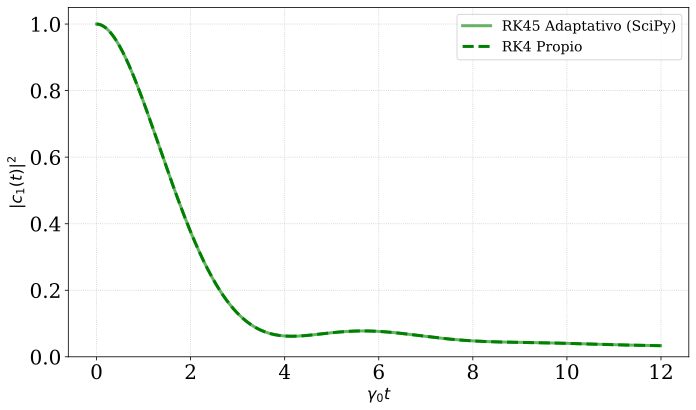

In [4]:
# Graficamos

plt.figure(figsize=(10,6))
t_gamma = gamma_0 * tiempos
#grafico rk45 (libreria)
plt.plot(t_gamma, prob_rk45, label='RK45 Adaptativo (SciPy)', color='green', linewidth=3, alpha=0.6)
#grafico rk4 (propio)
plt.plot(t_gamma, prob_rk4, label='RK4 Propio', color='green', linewidth = 3, linestyle='--')

plt.xlabel('$\gamma_0 t$')
plt.ylabel('$|c_1(t)|^2$')
plt.ylim([0, 1.05])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("grafico_rk445.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [5]:
# Calculamos la solución exacta con D_nu 

# Definimos la función Cil. Parabólica y su derivada (con relacion de recurrencia)

def D_nu(nu, z):
    return complex(mp.pcfd(nu, z)) #pcfd parabollic cylinder function tipo D

def D_nu_prima(nu, z):
    #definimos relac. de recurrencia
    return (z / 2.0) * D_nu(nu, z) - D_nu(nu + 1.0, z)

In [6]:
# Definimos las constantes A y B de la solución exacta

nu = 1j * (gamma_0 * lamda) / (2.0 * alpha)
eta = np.exp(-1j * np.pi / 4.0) * np.sqrt(alpha)
z_0 = np.exp(-1j * np.pi / 4.0) * np.sqrt(alpha) * (-1j * lamda /alpha)

a = D_nu(nu, z_0)
b = D_nu(nu, -z_0)
a_prima = D_nu_prima(nu, z_0)
b_prima = D_nu_prima(nu, -z_0)

c10 = 1.0 + 0j #condicio ninicial

# Definimos A y B
A = c10 * (b_prima + (lamda * b) / (2.0 * eta)) / ((a * b_prima) + (a_prima * b))
B = c10 * (a_prima - (lamda * a) / (2.0 * eta)) / ((a * b_prima) + (a_prima * b))

# Definimos el array para las probabilidsdes
prob_analitica = np.zeros(len(tiempos))

for i, t in enumerate(tiempos):
    # def z(t)
    z_t = np.exp(-1j * np.pi / 4.0) * np.sqrt(alpha) * (t - 1j * lamda / alpha)

    # par de soluciones posibles
    D_pos = D_nu(nu, z_t)
    D_neg = D_nu(nu, -z_t)

    c1_t = A * D_pos + B * D_neg #coef c1 analítico
    #prob final analitica
    prob_analitica[i] = np.exp(-lamda * t) * (np.abs(c1_t)**2)

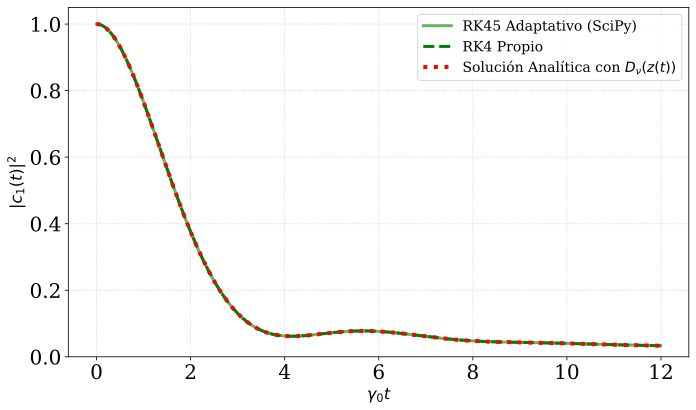

In [7]:
# agregamos la solucion analitica al gráfico anterior

plt.figure(figsize=(10,6))

#grafico rk45 (libreria)
plt.plot(t_gamma, prob_rk45, label='RK45 Adaptativo (SciPy)', color='green', linewidth=3, alpha=0.6)
#grafico rk4 (propio)
plt.plot(t_gamma, prob_rk4, label='RK4 Propio', color='green', linewidth = 3, linestyle='--')
#grafico D_nu exacto
plt.plot(t_gamma, prob_analitica, label=r'Solución Analítica con $D_{\nu}(z(t))$', color='red', linewidth = 4, linestyle='dotted')

plt.xlabel('$\gamma_0 t$')
plt.ylabel('$|c_1(t)|^2$')
plt.ylim([0, 1.05])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("grafico_rkanalitica.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [8]:
# Armamos la ecuación maestra de linblad

#escribimos los estados base
ket_e = qt.basis(2, 0)
ket_g = qt.basis(2, 1)

operador_e = ket_e * ket_e.dag() #proyector e-e de H_S
sigma_menos = qt.sigmam() #operador bajada 

def omega_t(t, args): # gap de energía definido por el detuning rampa lineal
    return args["omega_b"] - args["alpha"] * t
def H_S(t, args): # Hamiltoniano (dep. del tiempo) del sistema
    return omega_t(t, args) * operador_e

args_qt = {
    "omega_b" : omega_b,
    "alpha" : alpha
}
c_ops = [np.sqrt(gamma_0) * sigma_menos]
e_ops = [operador_e]
rho_0 = qt.ket2dm(ket_e)
# resolvemos 

res_linblad = qt.mesolve(H_S, rho_0, tiempos, c_ops, e_ops, args=args_qt)
prob_linblad = np.real(res_linblad.expect[0])
#Ec. Maestra de lindblad teórico
lin_teo = np.exp(-gamma_0 * tiempos)

C:\Users\fahum\anaconda3\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


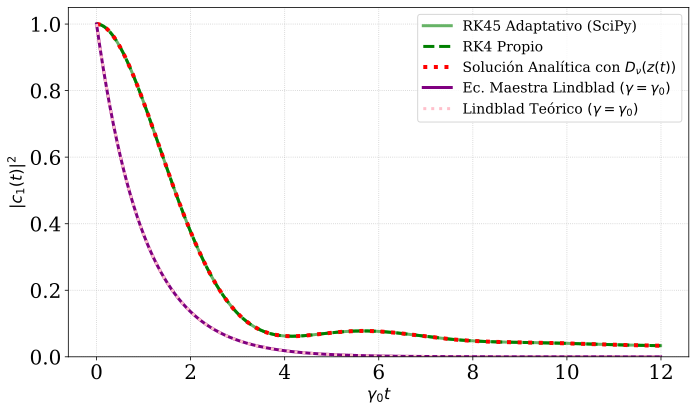

In [9]:
# Agregamos la solución con ecuación maestra al gráfico anterior

plt.figure(figsize=(10,6))

#grafico rk45 (libreria)
plt.plot(t_gamma, prob_rk45, label='RK45 Adaptativo (SciPy)', color='green', linewidth=3, alpha=0.6)
#grafico rk4 (propio)
plt.plot(t_gamma, prob_rk4, label='RK4 Propio', color='green', linewidth = 3, linestyle='--')
#grafico D_nu exacto
plt.plot(t_gamma, prob_analitica, label=r'Solución Analítica con $D_{\nu}(z(t))$', color='red', linewidth = 4, linestyle='dotted')
#grafico Linblad master equation
plt.plot(t_gamma, prob_linblad, label=r'Ec. Maestra Lindblad $(\gamma = \gamma_0)$', color='purple', linewidth=3)
plt.plot(t_gamma, prob_linblad, label=r'Lindblad Teórico $(\gamma = \gamma_0)$', color='pink', linewidth=3, linestyle='dotted')
plt.xlabel('$\gamma_0 t$')
plt.ylabel('$|c_1(t)|^2$')
plt.ylim([0, 1.05])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("grafico_rkanaliticalindblad.pdf", format="pdf", bbox_inches="tight")
plt.show()

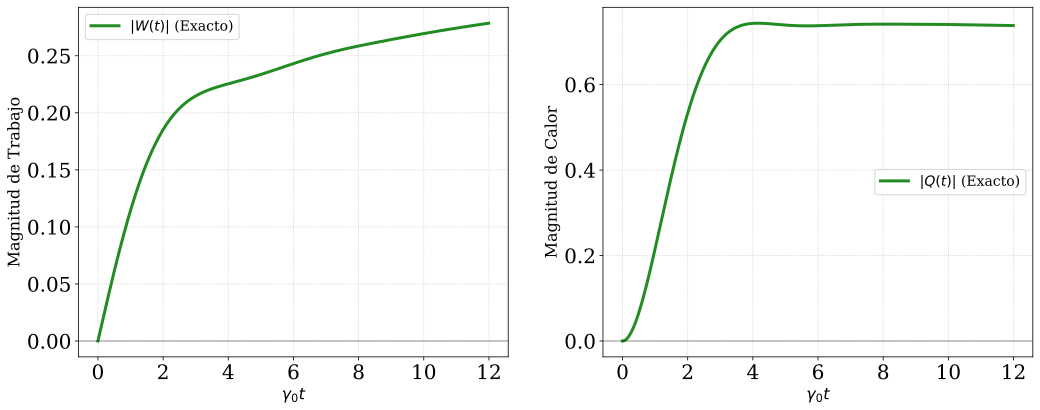

In [25]:
 # Calcular W y Q para analítica

d_prob_dt = np.gradient(prob_analitica, tiempos) #Derivada de c1^2
integrando_W = -alpha * prob_analitica #lo dice el nombre
omega_vals = omega_t(tiempos, args_qt) #función omega en cada t
integrando_Q = omega_vals * d_prob_dt #lo dice el nombre

# Integración de Q y W
W_exacto_t = cumulative_trapezoid(integrando_W, x=tiempos, initial=0)
Q_exacto_t = cumulative_trapezoid(integrando_Q, x=tiempos, initial=0)

# Calculamos magnitud para graficar
mag_W_t = np.abs(W_exacto_t)
mag_Q_t = np.abs(Q_exacto_t)

#Graficamos W y Q lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))

#Grafica de W (izq)
ax1.plot(gamma_0 * tiempos, mag_W_t, label=r'$|W(t)|$ (Exacto)', color='#228B22', linewidth=3)
ax1.set_xlabel(r'$\gamma_0 t$')
ax1.set_ylabel(r'Magnitud de Trabajo')
ax1.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

#Grafica de Q (der)
ax2.plot(gamma_0 * tiempos, mag_Q_t, label=r'$|Q(t)|$ (Exacto)', color='#228B22', linewidth=3)
ax2.set_xlabel(r'$\gamma_0 t$')
ax2.set_ylabel(r'Magnitud de Calor')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
#plt.savefig("Q_W_exaccto", format="pdf", bbox_inches="tight") #por si lo necesito
plt.show()

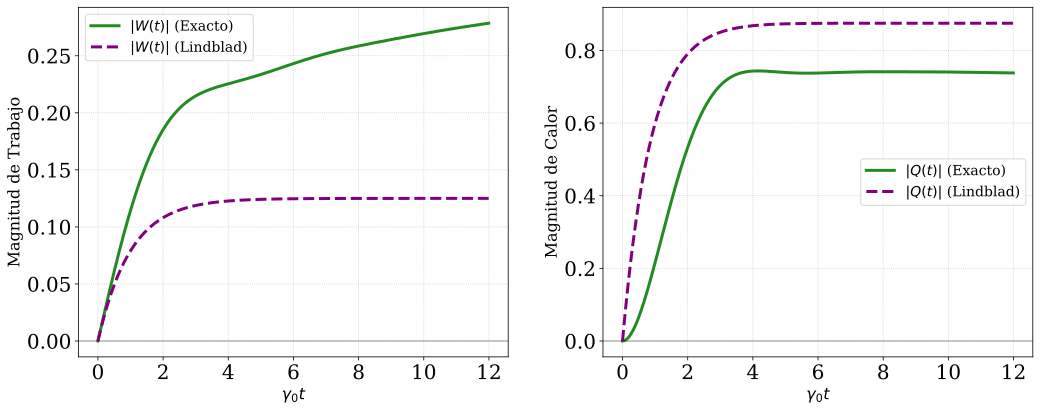

In [27]:
#Calcular Q y W para Lindblad

d_prob_dt_linblad = np.gradient(prob_linblad, tiempos)
integrando_W_linblad = -alpha * prob_linblad
integrando_Q_linblad = omega_vals * d_prob_dt_linblad

#integramos Q y W
W_linblad_t = cumulative_trapezoid(integrando_W_linblad, x=tiempos, initial=0)
Q_linblad_t = cumulative_trapezoid(integrando_Q_linblad, x=tiempos, initial=0)

#magnitudes
mag_W_linblad = np.abs(W_linblad_t)
mag_Q_linblad = np.abs(Q_linblad_t)

#comparamos con grafica anterior

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# grafico comparacion W (izq)
ax1.plot(gamma_0 * tiempos, mag_W_t, label=r'$|W(t)|$ (Exacto)', color='#228B22', linewidth=3)
ax1.plot(gamma_0 * tiempos, mag_W_linblad, label=r'$|W(t)|$ (Lindblad)', color='purple', linewidth=3, linestyle='--')

ax1.set_xlabel(r'$\gamma_0 t$')
ax1.set_ylabel(r'Magnitud de Trabajo')
ax1.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# grafico comparacion Q (der)
ax2.plot(gamma_0 * tiempos, mag_Q_t, label=r'$|Q(t)|$ (Exacto)', color='#228B22', linewidth=3)
ax2.plot(gamma_0 * tiempos, mag_Q_linblad, label=r'$|Q(t)|$ (Lindblad)', color='purple', linewidth=3, linestyle='--')

ax2.set_xlabel(r'$\gamma_0 t$')
ax2.set_ylabel(r'Magnitud de Calor')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.savefig("Q_W_comparacion.pdf", format="pdf", bbox_inches="tight")
plt.show()